In [1]:
import os
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt

## Food101 Data Ingestion

Load the [Food101 dataset](https://huggingface.co/datasets/ethz/food101) from HuggingFace — 101,000 images across 101 food categories, split into train (75,750) and validation (25,250).

In [ ]:
# Load train and validation splits from HuggingFace
# dataset = load_dataset("ethz/food101")

# train_ds = dataset["train"]
# val_ds   = dataset["validation"]

# print(f"Train samples : {len(train_ds):,}")
# print(f"Val   samples : {len(val_ds):,}")
# print(f"Features      : {train_ds.features}")

In [7]:
# (Optional) Save dataset to disk for faster reloads in subsequent sessions
SAVE_DIR = "./food101_cache"
# dataset.save_to_disk(SAVE_DIR)
# print(f"Dataset saved to {os.path.abspath(SAVE_DIR)}")

# To reload later:
from datasets import load_from_disk
dataset = load_from_disk(SAVE_DIR)
train_ds = dataset["train"]
val_ds   = dataset["validation"]

In [8]:
# Class labels
label_names = train_ds.features["label"].names
num_classes = len(label_names)
print(f"Number of classes: {num_classes}")
print(f"First 10 classes : {label_names[:10]}")

Number of classes: 101
First 10 classes : ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


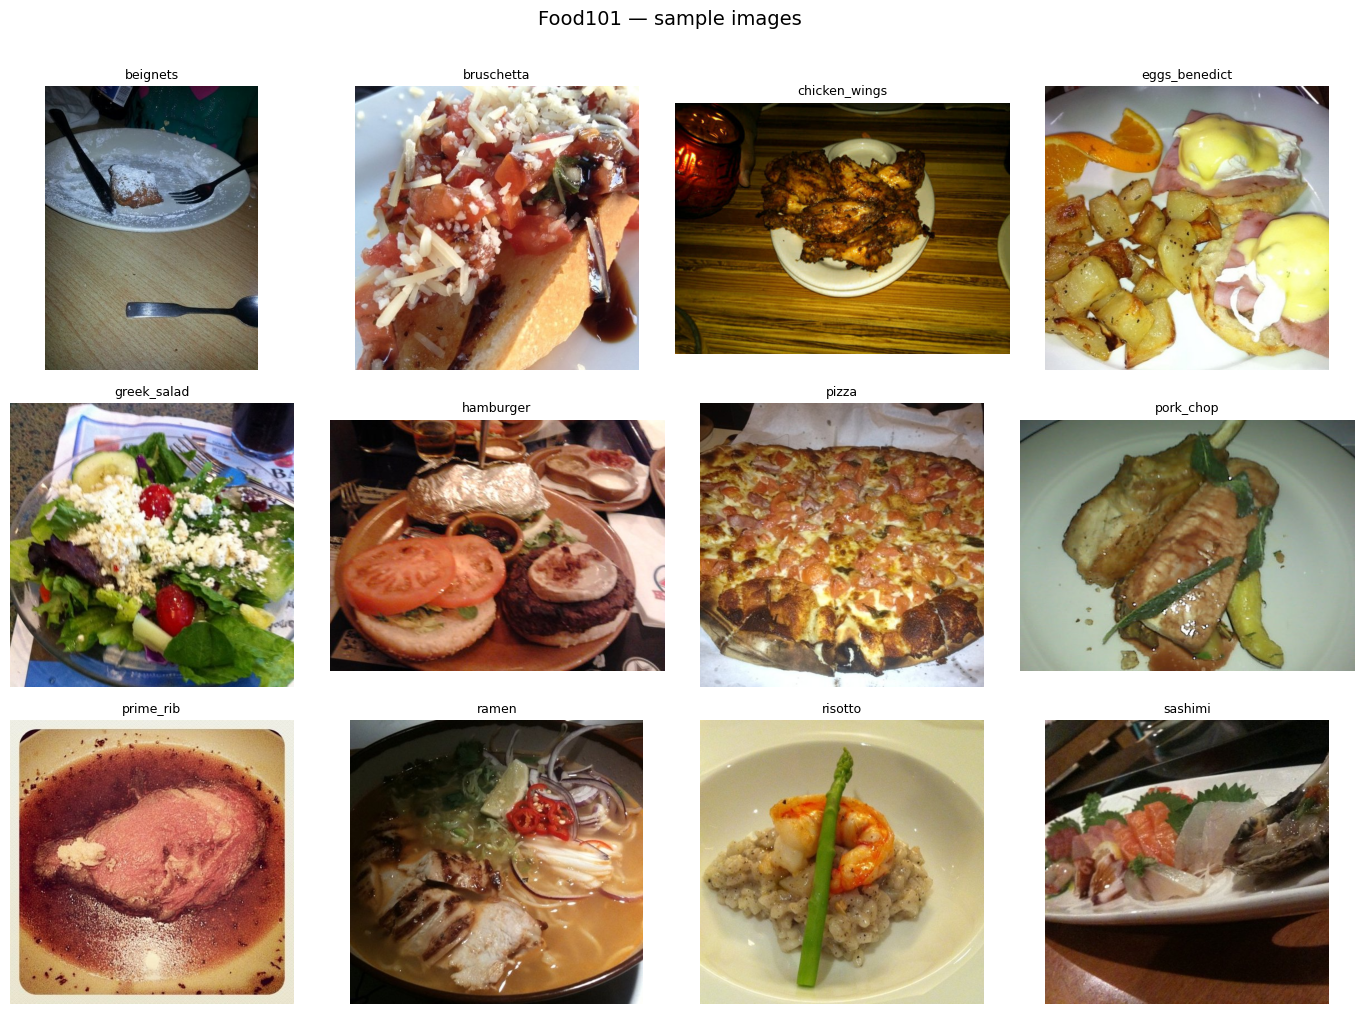

In [9]:
# Visualise a sample grid (one image per class, first 12 classes)
sample = train_ds[0]  # a single dataset item: {'image': <PIL.Image>, 'label': <int>}

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

# Build a quick label->index map for the first sample of each class
label_to_idx = {}
for i, sample in enumerate(train_ds):
    lbl = sample["label"]
    if lbl not in label_to_idx:
        label_to_idx[lbl] = i
    if len(label_to_idx) == 12:
        break

for ax, (lbl, idx) in zip(axes, sorted(label_to_idx.items())):
    img = train_ds[idx]["image"]
    ax.imshow(img)
    ax.set_title(label_names[lbl], fontsize=9)
    ax.axis("off")

plt.suptitle("Food101 — sample images", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()